# speed-watch — Car Detection & Tracking (v1)

Detect and track race cars in video footage using YOLOv8 + ByteTrack. This notebook is the foundation for the larger Racing Vision project (lap timing, speed estimation, overtakes, racing line) — v1 scope is **detection + tracking only**.

**Inputs:**
- Roboflow dataset (`data/roboflow_dataset/`) — 292 aerial/top-down images, single class `car`, YOLOv8 format.
- Two YouTube racing clips (`videos/racing_clip1.mp4`, `videos/racing_clip2.mp4`), likely ground-level/trackside angle.

**Key risk:** camera angle mismatch between the aerial training set and the ground-level clips — validated in the Angle Mismatch section below before any fine-tuning is attempted.

**Pipeline:** frame extraction (OpenCV) → detection (YOLOv8, via `pipeline.CarDetector`) → tracking (ByteTrack, via `pipeline.CarTracker`) → annotated video + CSV log. Reusable pipeline code lives in `pipeline/`; this notebook drives experiments and records results. `main.py` at the repo root runs the full pipeline end-to-end on a clip.

## Setup

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

import config as cfg
from pipeline import CarDetector, annotate_frame, sample_frames

ROBOFLOW_DIR = cfg.ROOT_DIR / "data" / "roboflow_dataset"
CLIP_PATHS = [cfg.VIDEOS_DIR / "racing_clip1.mp4", cfg.VIDEOS_DIR / "racing_clip2.mp4"]

cfg.OUTPUT_VIDEOS_DIR.mkdir(exist_ok=True)
cfg.MODELS_DIR.mkdir(exist_ok=True)

objc[20397]: Class AVFFrameReceiver is implemented in both /opt/homebrew/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10b1143a8) and /opt/homebrew/lib/python3.14/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x11e1a43a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[20397]: Class AVFAudioReceiver is implemented in both /opt/homebrew/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10b1143f8) and /opt/homebrew/lib/python3.14/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x11e1a43f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [2]:
def show_frames(frames, titles=None, cols=3, figsize_per=(4, 3)):
    """Display a list of BGR frames inline in a grid."""
    rows = (len(frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per[0] * cols, figsize_per[1] * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for i, ax in enumerate(axes):
        if i < len(frames):
            ax.imshow(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB))
            if titles:
                ax.set_title(titles[i], fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Track A: Pretrained YOLOv8 Baseline

In [3]:
model_pretrained = CarDetector.pretrained(weights=str(cfg.PRETRAINED_WEIGHTS))

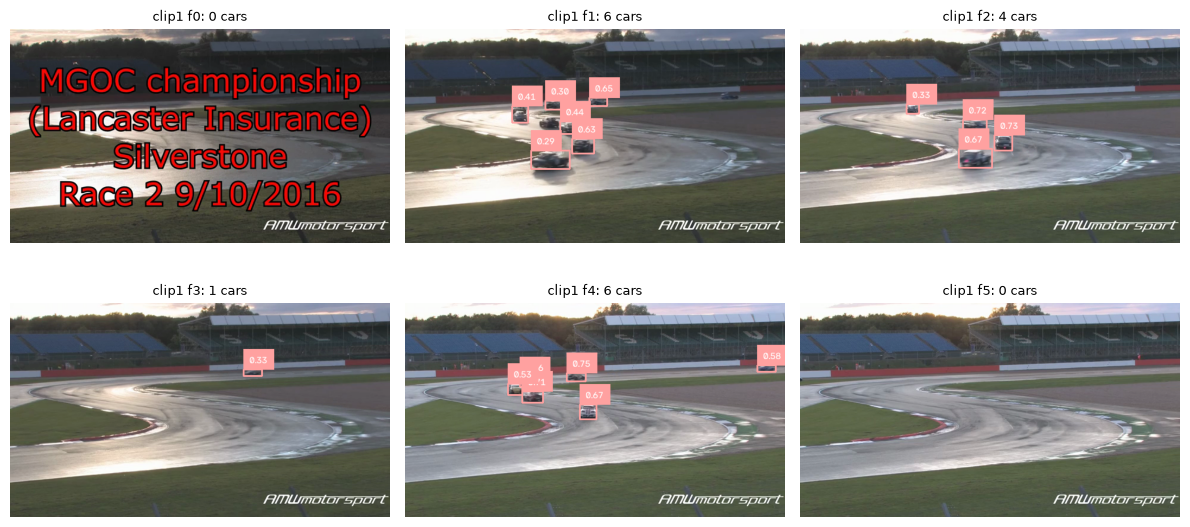

In [4]:
clip1_frames = sample_frames(CLIP_PATHS[0], n=6)
clip1_detections = [model_pretrained.predict(f) for f in clip1_frames]
clip1_annotated = [annotate_frame(f, d) for f, d in zip(clip1_frames, clip1_detections)]
clip1_counts = [len(d) for d in clip1_detections]

for i, frame in enumerate(clip1_annotated):
    cv2.imwrite(str(cfg.OUTPUT_VIDEOS_DIR / f"trackA_pretrained_clip1_frame{i}.jpg"), frame)

show_frames(clip1_annotated, titles=[f"clip1 f{i}: {c} cars" for i, c in enumerate(clip1_counts)])

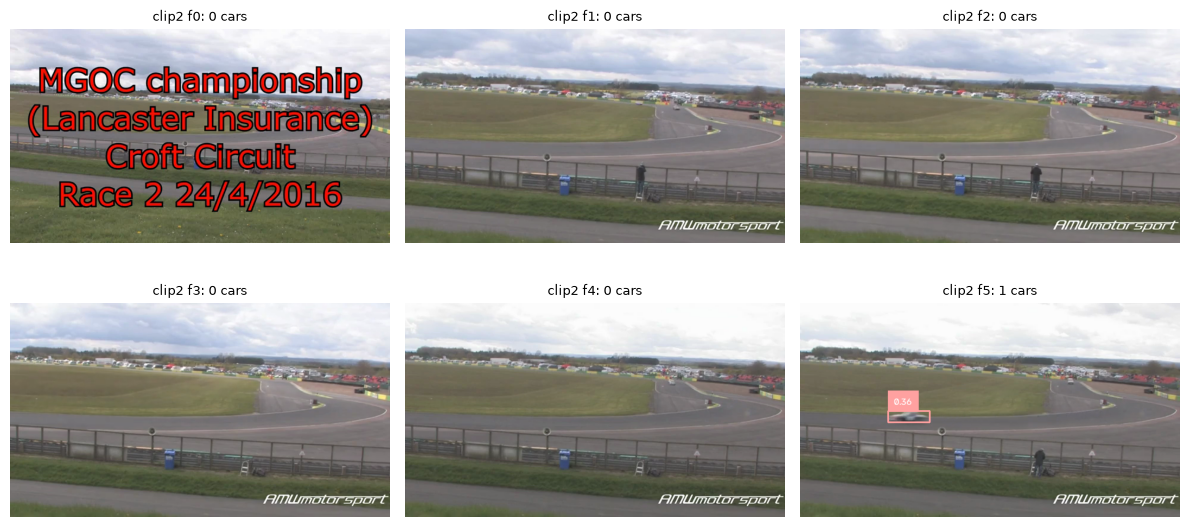

In [5]:
clip2_frames = sample_frames(CLIP_PATHS[1], n=6)
clip2_detections = [model_pretrained.predict(f) for f in clip2_frames]
clip2_annotated = [annotate_frame(f, d) for f, d in zip(clip2_frames, clip2_detections)]
clip2_counts = [len(d) for d in clip2_detections]

for i, frame in enumerate(clip2_annotated):
    cv2.imwrite(str(cfg.OUTPUT_VIDEOS_DIR / f"trackA_pretrained_clip2_frame{i}.jpg"), frame)

show_frames(clip2_annotated, titles=[f"clip2 f{i}: {c} cars" for i, c in enumerate(clip2_counts)])

In [6]:
print("clip1 per-frame vehicle counts:", clip1_counts)
print("clip2 per-frame vehicle counts:", clip2_counts)
print(f"clip1 mean: {sum(clip1_counts)/len(clip1_counts):.2f}, clip2 mean: {sum(clip2_counts)/len(clip2_counts):.2f}")

clip1 per-frame vehicle counts: [0, 6, 4, 1, 6, 0]
clip2 per-frame vehicle counts: [0, 0, 0, 0, 0, 1]
clip1 mean: 2.83, clip2 mean: 0.17


**Track A summary:** pretrained `yolov8n.pt` (COCO car/bus/truck classes) run on 6 sampled frames from each clip.

- clip1 per-frame counts: `[0, 6, 4, 1, 6, 0]` — mean **2.83**
- clip2 per-frame counts: `[0, 0, 0, 0, 0, 1]` — mean **0.17**

clip2 detection rate is far below the ≥80%-of-visible-cars target — pretrained COCO weights are struggling on that clip. Worth checking camera angle/scale/resolution differences before concluding fine-tuning (Track B) is the fix, since Track B trains on aerial data and may not transfer to a ground-level clip either. Annotated frames saved to `output_videos/trackA_pretrained_*`.

## Angle Mismatch Validation

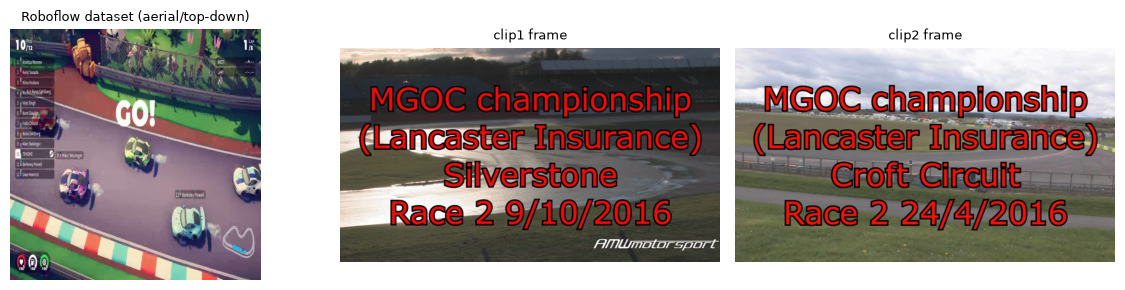

In [7]:
roboflow_train_images = sorted((ROBOFLOW_DIR / "train" / "images").glob("*.jpg"))
roboflow_sample = cv2.imread(str(roboflow_train_images[0]))

clip_sample_frames = [sample_frames(p, n=1)[0] for p in CLIP_PATHS]

show_frames(
    [roboflow_sample] + clip_sample_frames,
    titles=["Roboflow dataset (aerial/top-down)", "clip1 frame", "clip2 frame"],
)

**Observed angle difference:** the Roboflow training image is aerial/top-down — cars appear as small rectangular blobs viewed from directly above. Both clip frames are ground-level/trackside — cars appear side-on or 3/4 view at a much larger scale relative to the frame, with track surface occupying most of the background instead of framing the car from above.

**Implication for Track B:** fine-tuning on this Roboflow set teaches the model to recognize the aerial silhouette of a car, not the ground-level profile seen in the clips. This mismatch likely explains part of Track A's weak clip2 detection rate (mean 0.17 cars/frame) — the pretrained COCO weights already understand ground-level cars reasonably, so a bad fine-tune could plausibly make clip performance *worse*, not better, by pulling the model toward aerial-only features. Track B is still worth running per the PRD, but expectations should be set low for transfer to these two clips specifically, and results compared side-by-side against Track A rather than assumed superior.

## Track B: Fine-tuned YOLOv8 on Roboflow Dataset

## Comparison: Pretrained vs. Fine-tuned

## Tracking Demo: ByteTrack

## Conclusion